In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import time

In [3]:
from mytools import extract_hours, visualize_dag, pert_sample

In [4]:
sns.set_theme()

## Baseline schedule

In [5]:
file_path='dataset/C2018-13 Christmas market.xlsx'

In [6]:
# Read the baseline schedule
df=pd.read_excel(file_path, sheet_name='Baseline Schedule',skiprows=1,index_col=0)
df.drop(0,axis=0,inplace=True) # drop the first row
df['DurationH']=df['Duration'].apply(lambda x: extract_hours(x)) # extract the duration in hours
df_project=df[['Name', 'Successors', 'DurationH', 'Total Cost']].copy()
df_project.columns=['Name', 'Successors', 'Duration', 'TotalCost']
df_project.head()

,Name,Successors,Duration,TotalCost
ID,,,,
1,START,FS2,0,0
2,Creation of the activities plan and location,FS3,40,4000
3,Asking City Hall Permission / License - email,FS4,240,200
4,Receiving acceptance,FS5;FS6;FS7;FS8;FS21,10,200
5,Creation of a safety plan,FS9,16,640


In [7]:
# Read the risk analysis and merge with the project dataframe
df=pd.read_excel(file_path, sheet_name='Risk Analysis',skiprows=1,usecols=range(7),index_col=0)
df.drop(0,axis=0,inplace=True) # drop the first row
df_project=pd.merge(df_project,df[['Optimistic', 'Most Probable','Pessimistic']],left_index=True,right_index=True)

# Compute the optimistic, most probable, and pessimistic durations in hours
df_project['OptimisticH']=df_project['Optimistic']*df_project['Duration']/100
df_project['MostProbableH']=df_project['Most Probable']*df_project['Duration']/100
df_project['PessimisticH']=df_project['Pessimistic']*df_project['Duration']/100

# Drop the original Optimistic, Most Probable, and Pessimistic columns
df_project.drop(['Optimistic', 'Most Probable','Pessimistic'],axis=1,inplace=True)

# Rename the columns
df_project.columns=['Name', 'Successors', 'Duration', 'TotalCost', 'Optimistic', 'MostProbable', 'Pessimistic']
df_project.head()

,Name,Successors,Duration,TotalCost,Optimistic,MostProbable,Pessimistic
ID,,,,,,,
1,START,FS2,0,0,0.0,0.0,0.0
2,Creation of the activities plan and location,FS3,40,4000,32.0,44.0,48.0
3,Asking City Hall Permission / License - email,FS4,240,200,192.0,264.0,288.0
4,Receiving acceptance,FS5;FS6;FS7;FS8;FS21,10,200,8.0,11.0,12.0
5,Creation of a safety plan,FS9,16,640,12.8,17.6,19.2


In [8]:
# Build the Activity on Node (AON) network
# The activity‐on‐node (AON) network is modeled as a Networkx directed acyclic 
Go=nx.DiGraph()
for i in df_project.index:
    mean_d=(df_project.loc[i,'Optimistic']+4*df_project.loc[i,'MostProbable']+df_project.loc[i,'Pessimistic'])/6
    Go.add_node(i,
               planned_value = df_project.loc[i,'TotalCost'], # The planned value
               optimistic = df_project.loc[i,'Optimistic'], # The optimistic duration
               pessimistic = df_project.loc[i,'Pessimistic'], # The pessimistic duration
               mostlikely = df_project.loc[i,'MostProbable'], # The most likely duration
               mean_duration=mean_d) # The mean duration
    if not pd.isna(df_project.loc[i,'Successors']):
        for s in df_project.loc[i,'Successors'].split(";"):
            Go.add_edge(i,int(s[2:]),type=s[:2])
print(f'AON graph with {Go.number_of_nodes()} nodes and {Go.number_of_edges()} edges')
print('Is G aperiodic?',nx.is_aperiodic(Go))  

AON graph with 33 nodes and 45 edges
Is G aperiodic? True


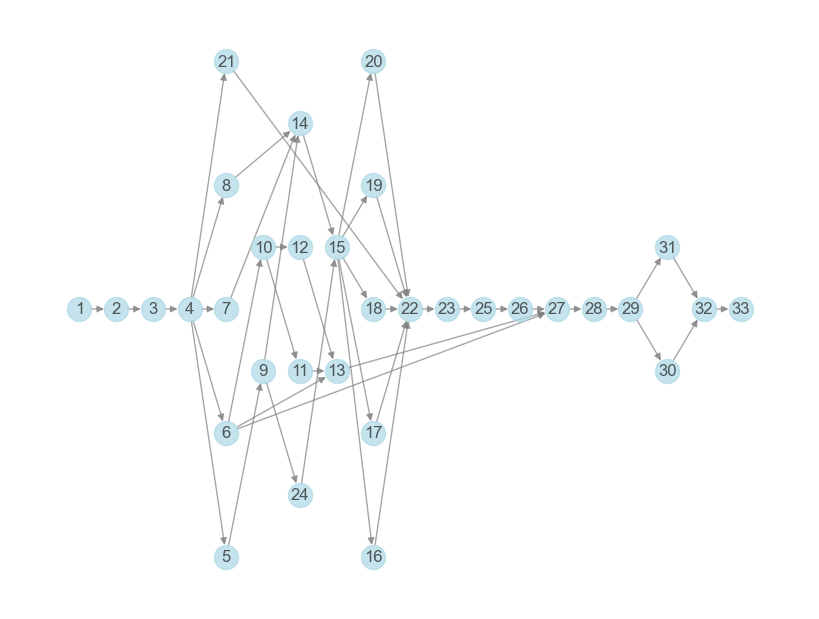

In [9]:
# Visualize the AON network
visualize_dag(Go)

## Functions for simulation

In [10]:
# Draw random durations for the activities following a PERT distribution
def draw_random_durations(G,control=None,pert_sample=pert_sample):
    nx.set_node_attributes(G,0,'duration')
    if control is None:
        for n in list(G.nodes())[1:-1]: # Skip the start and end nodes
            G.nodes[n]['duration']=pert_sample(G.nodes[n]['optimistic'], G.nodes[n]['mostlikely'], G.nodes[n]['pessimistic'],size=1)[0]
    else:
        for n in control.index[1:-1]: # Skip the start and end nodes
          
            if control.loc[n,'PercentageCompleted']==1: # completed activity
                G.nodes[n]['duration']=control.loc[n,'ActualDuration'] # the duration is the actual duration
            
            elif control.loc[n,'PercentageCompleted']>0 and control.loc[n,'PercentageCompleted'] <1: # ongoing activity
                G.nodes[n]['duration']=pert_sample(G.nodes[n]['optimistic'], G.nodes[n]['mostlikely'], G.nodes[n]['pessimistic'],
                                                   elapsed_time=control.loc[n,'ActualDuration'],
                                                   complete_percent=control.loc[n,'PercentageCompleted'],
                                                   size=1)[0]
            else: # not started activity
                G.nodes[n]['duration']=pert_sample(G.nodes[n]['optimistic'], G.nodes[n]['mostlikely'], G.nodes[n]['pessimistic'],size=1)[0]


In [11]:
# Compute the start time of activities based on the dependencies
def compute_times(G,time='duration'):
    # time: duration or meanduration
    start_time={n:0 for n in G.nodes()} # initialize the start time dictionary
    for n in nx.topological_sort(G): # follow a list of nodes in topologically sorted order
        end=start_time[n] + G.nodes[n][time] # end time
        for j in G.neighbors(n):
            if G.edges[n,j]['type']=='FS': # Finish to Start dependency
                start_time[j]=np.max([start_time[j],end])
            if G.edges[n,j]['type']=='SS': # Start to Start dependency
                start_time[j]=np.max([start_time[j],start_time[n]])
    return start_time


In [12]:
# Monte-Carlo simulation of the project
def simulation(G,experiment,control=None,Nruns=10000,echo=False):
    sim_list=list() # list of dictionaries with runs
    if echo: print('Starting simulation...')
    for m in range(Nruns):
        # Draw durations
        draw_random_durations(G,control)
        # Save run
        sim={'duration'+str(i):G.nodes[i]['duration'] for i in G.nodes()}
        sim.update({'baseline_duration':np.max([t for t in compute_times(G,time='mean_duration').values()])})
        sim.update({'actual_duration':np.max([t for t in compute_times(G,time='duration').values()])})
        sim_list.append(sim)
        if echo: print(m)
    if echo: print('... end simulation')
    pd.DataFrame.from_dict(sim_list).to_csv('./data/simulation_christmas_market_' + experiment+ '.csv')

## Contol Accounts

### Example CA=12 (EV=25%)

In [14]:
# Read the control account data
N=12 # The time period

df=pd.read_excel(file_path, sheet_name='TP'+str(N),skiprows=3,index_col=0)

ev_percent=df.loc[0,'Percentage Completed'] # Read the EV%
print(f'EV%={ev_percent}')

df.drop(0,axis=0,inplace=True) # drop the first row
dfc=df[['Actual Duration', 'Actual Cost','Percentage Completed', 'Earned Value (EV)', 'Planned Value (PV)']].copy()
dfc['Actual Duration']=dfc['Actual Duration'].apply(lambda x: extract_hours(x))
dfc.columns=['ActualDuration', 'ActualCost', 'PercentageCompleted', 'EarnedValue', 'PlannedValue']
dfc.head()

EV%=0.251570574820345


,ActualDuration,ActualCost,PercentageCompleted,EarnedValue,PlannedValue
ID,,,,,
1,0,0,1.0,0.0,0
2,59,5900,1.0,4000.0,4000
3,339,200,1.0,200.0,200
4,12,200,1.0,200.0,200
5,22,880,1.0,640.0,640


In [100]:
# Simulations from the baseline schedule
start_time = time.time()
N=1000
simulation(Go.copy(),experiment='test0',control=None,Nruns=N)
print(f"Monte Carlo Simulation took {time.time() - start_time} seconds to run {N} samples")

Monte Carlo Simulation took 4.02738881111145 seconds to run 1000 samples


In [101]:
# Simulations from EV=0
df_sim=pd.read_csv('./data/simulation_christmas_market_test0.csv')

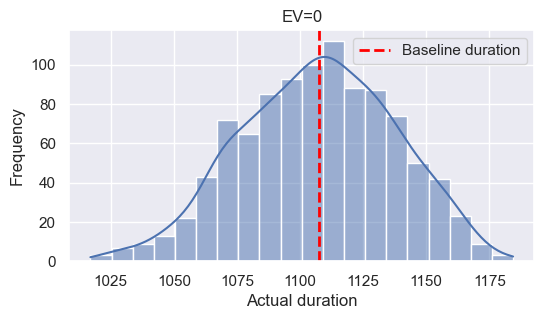

In [102]:
# Histogram of actual durations
g=sns.histplot(df_sim['actual_duration'],kde=True)
plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
plt.legend()
g.set_xlabel('Actual duration')
g.set_ylabel('Frequency')
g.set_title('EV=0')
g.figure.set_size_inches(6,3)

In [103]:
# Simulations from CA
start_time = time.time()
N=1000
simulation(Go.copy(),experiment='test1',control=dfc,Nruns=N)
print(f"Monte Carlo Simulation took {time.time() - start_time} seconds to run {N} samples")

Monte Carlo Simulation took 5.216454982757568 seconds to run 1000 samples


In [104]:
# Simulations from CA
df_sim=pd.read_csv('./data/simulation_christmas_market_test1.csv')

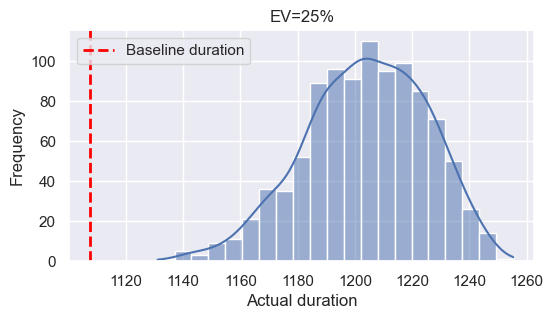

In [105]:
# Histogram of actual durations
g=sns.histplot(df_sim['actual_duration'],kde=True)
plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
plt.legend()
g.set_xlabel('Actual duration')
g.set_ylabel('Frequency')
g.set_title('EV='+str(int(ev_percent*100))+'%')
g.figure.set_size_inches(6,3)

### Simulation of all control accounts

In [15]:
Nca=37 # Number of control accounts (tracking points)
Ns=1000 # Number of simulation runs

In [16]:
# Simulations from CA
start_time = time.time()
for tp in range(Nca+1):
    
    if tp==0: # Baseline schedule
        print('Simulation for the baseline schedule ...')
        simulation(Go.copy(),experiment='tp0_ev0',control=None,Nruns=Ns)
    else:
        # Read the control account data
        df=pd.read_excel(file_path, sheet_name='TP'+str(tp),skiprows=3,index_col=0)
        ev_percent=df.loc[0,'Percentage Completed'] # Read the EV%
        df.drop(0,axis=0,inplace=True) # drop the first row
        dfc=df[['Actual Duration', 'Actual Cost','Percentage Completed', 'Earned Value (EV)', 'Planned Value (PV)']].copy()
        dfc['Actual Duration']=dfc['Actual Duration'].apply(lambda x: extract_hours(x)) # extract the duration in hours
        dfc.columns=['ActualDuration', 'ActualCost', 'PercentageCompleted', 'EarnedValue', 'PlannedValue'] # rename the columns

        # Simulations from CA
        print('Simulation for TP'+str(tp)+' ...')
        simulation(Go.copy(),experiment='tp'+str(tp)+"_ev" +str(round(ev_percent,4)),control=dfc,Nruns=Ns)
print(f"Monte Carlo Simulation took {time.time() - start_time} seconds to run {(Nca+1)*Ns} samples")


Simulation for the baseline schedule ...
Simulation for TP1 ...
Simulation for TP2 ...
Simulation for TP3 ...
Simulation for TP4 ...
Simulation for TP5 ...
Simulation for TP6 ...
Simulation for TP7 ...
Simulation for TP8 ...
Simulation for TP9 ...
Simulation for TP10 ...
Simulation for TP11 ...
Simulation for TP12 ...
Simulation for TP13 ...
Simulation for TP14 ...
Simulation for TP15 ...
Simulation for TP16 ...
Simulation for TP17 ...
Simulation for TP18 ...
Simulation for TP19 ...
Simulation for TP20 ...
Simulation for TP21 ...
Simulation for TP22 ...
Simulation for TP23 ...
Simulation for TP24 ...
Simulation for TP25 ...
Simulation for TP26 ...
Simulation for TP27 ...
Simulation for TP28 ...
Simulation for TP29 ...
Simulation for TP30 ...
Simulation for TP31 ...
Simulation for TP32 ...
Simulation for TP33 ...
Simulation for TP34 ...
Simulation for TP35 ...
Simulation for TP36 ...
Simulation for TP37 ...
Monte Carlo Simulation took 186.81216764450073 seconds to run 38000 samples


### Histogram of actual durations

In [17]:
import os
import re

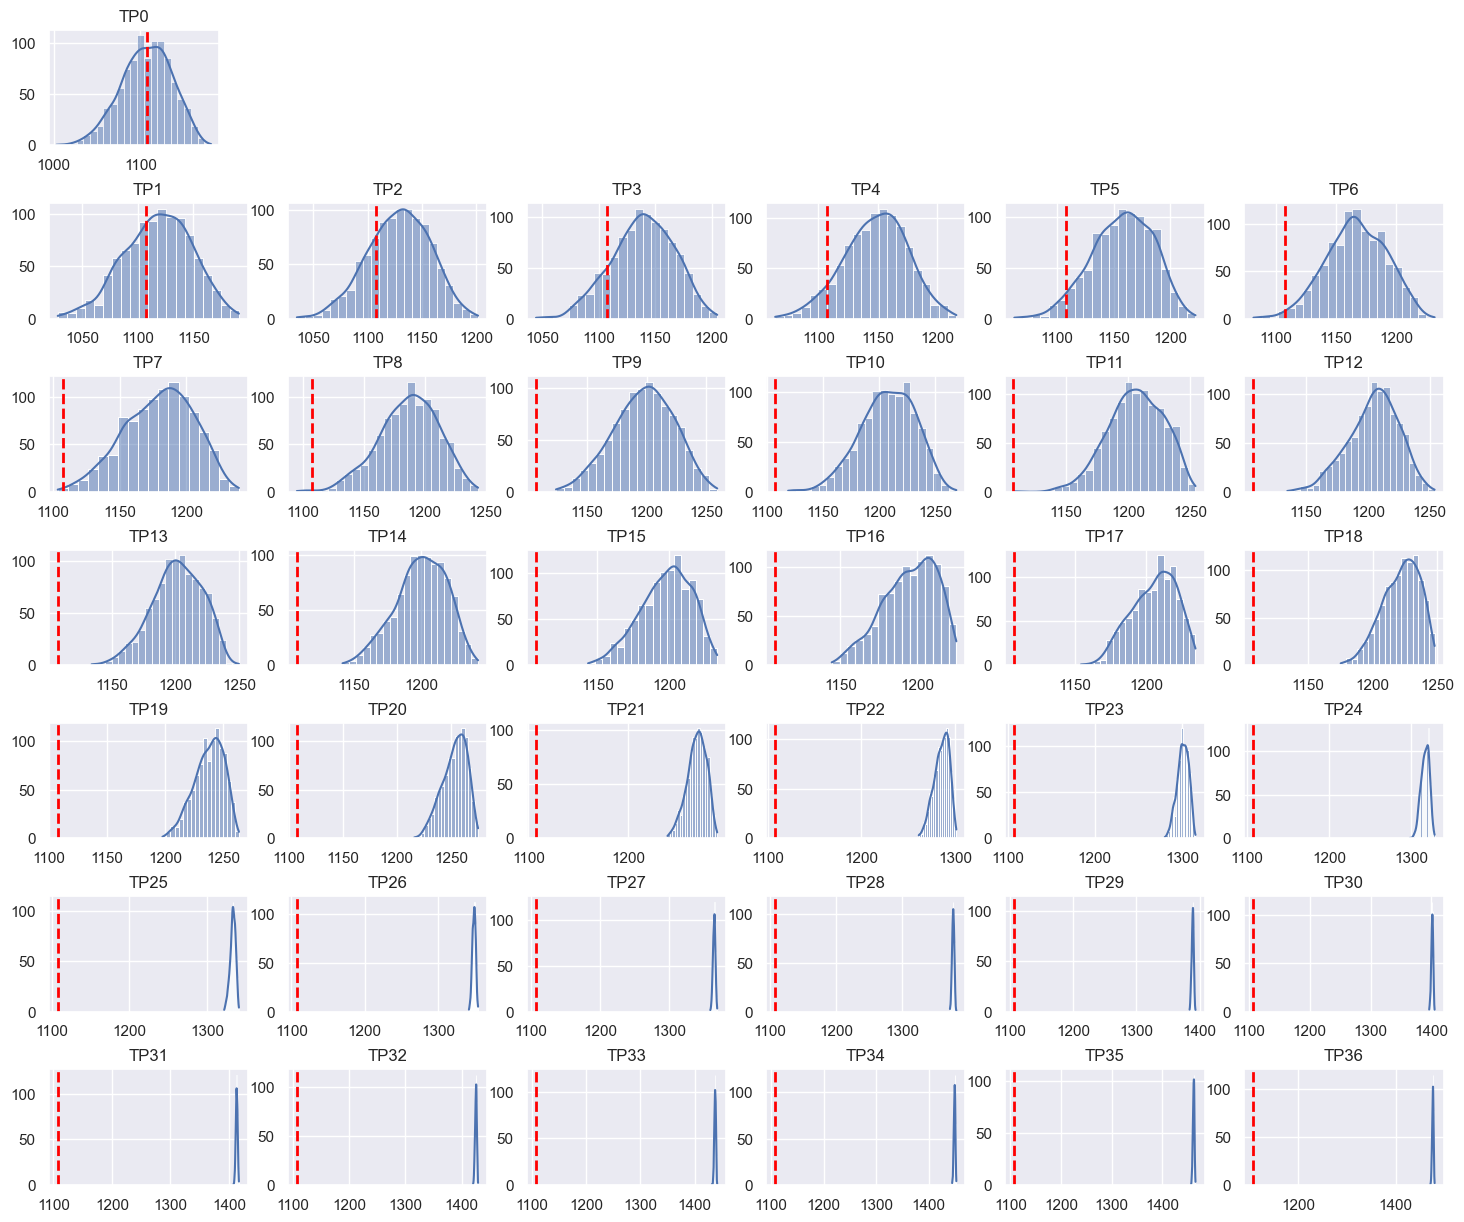

In [21]:
# Read the simulation files
siml=[file for file in os.listdir("./data/") if 'simulation_christmas_market_tp' in file]
siml=[(int(re.search(r'tp(\d+)', file).group(1)), re.search(r'ev([\d.]+)', file).group(1)[:-1],file) for file in siml] 
siml=sorted(siml,key=lambda x: x[0])

# Plot the histograms
plt.figure(figsize=(18,15))

data=siml[0] # Baseline schedule
df_sim=pd.read_csv('./data/'+data[2])
tp = data[0]
ev = data[1]
plt.subplot(7,7,1)
g=sns.histplot(df_sim['actual_duration'],kde=True)
plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
g.set_xlabel('')
g.set_ylabel('')
g.set_title('TP'+str(tp))

for i,data in enumerate(siml):
    if (i>0) and (i<Nca): # skip the baseline schedule and the last control account
        df_sim=pd.read_csv('./data/'+data[2])
        tp = data[0]
        ev = data[1]
        plt.subplot(7,6, i+6)
        g=sns.histplot(df_sim['actual_duration'],kde=True)
        plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
        g.set_xlabel('')
        g.set_ylabel('')
        g.set_title('TP'+str(tp))

plt.subplots_adjust(hspace=0.5)
